# Clustering whole-trajectory IDK embeddings

Compare **HDBSCAN** (density-based clusters and noise) with **spectral clustering**
(a fixed number of groups). Color **UMAP** and **t-SNE** by the HDBSCAN assignments,
then show the spectral assignments on the same coordinates.

Clustering uses the original IDK embedding geometry, never the 2D projections.
Checkpoint and return metadata are used only afterward to interpret the clusters.
Here, “whole” means a whole **prepared segment**, not necessarily the original episode.

Use the project's notebook environment (`python -m pip install -e ".[nb]"`) and run
all cells from the repository root or `notebooks/`. Only the embedding artifact is
needed; no fitting, raw trajectory loading, or re-embedding occurs.


In [1]:
import json
from importlib.metadata import version
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.manifold import TSNE
from umap import UMAP

from cartpole_idk.analytics.clustering import cluster_units
from cartpole_idk.analytics.evaluation import cluster_summary, evaluate_clusters
from cartpole_idk.analytics.metrics import pairwise
from cartpole_idk.artifacts import EmbeddingArtifact
from cartpole_idk.model import ClusterConfig

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Run from the repository root or notebooks directory.")

ARTIFACT_DIR = ROOT / (
    "artifacts/embeddings/200000-iter_nominal_500_episodes/"
    "psi-32_t-100_transition/10K-natfail-100ep_200K-nom-100ep/whole"
)
OUTPUT_DIR = ROOT / "artifacts/analysis/cluster-example-whole"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
MIN_CLUSTER_SIZE = 10
MIN_SAMPLES = 5
SPECTRAL_CLUSTERS = 2
UMAP_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
TSNE_PERPLEXITY = 30.0

Matplotlib is building the font cache; this may take a moment.


/Users/dma0523/code/research/cartpole-idk/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the artifact and inspect its population

Rows remain in artifact order throughout. `source_return` describes the original
rollout; `segment_return` and `raw_length` describe the prepared data being embedded.
The preparation `success` flag is a source-length threshold label, not a cluster label.


In [2]:
artifact = EmbeddingArtifact.load(ARTIFACT_DIR)
embedded = artifact.embeddings
units = pd.DataFrame([unit.record() for unit in embedded.units])
assert artifact.config.unit.mode == "whole"
assert embedded.values.shape[0] == len(units)

print(f"{len(units)} units × {embedded.values.shape[1]} embedding features")
print(
    f"Representation: {artifact.config.fit.idk.representation}; psi={embedded.psi}; t={embedded.t}"
)
display(
    units.groupby("checkpoint_id").agg(
        units=("unit_id", "size"),
        mean_source_return=("source_return", "mean"),
        mean_segment_return=("segment_return", "mean"),
        min_segment_length=("raw_length", "min"),
        max_segment_length=("raw_length", "max"),
        successful_sources=("success", "sum"),
    )
)

200 units × 3200 embedding features
Representation: transition; psi=32; t=100


,units,mean_source_return,mean_segment_return,min_segment_length,max_segment_length,successful_sources
checkpoint_id,,,,,,
step_000010000,100,97.74,94.09,81,100,0
step_000200000,100,500.00,100.00,100,100,100


## Cluster in the original embedding space

IDK distance is `||embedding_i - embedding_j|| / sqrt(t)`. HDBSCAN uses this distance
with `min_cluster_size=10` and `min_samples=5`; label **-1** means noise. Its membership
strength measures association with the assigned cluster, not probability of failure.

Spectral clustering uses native IDK affinity and requests **two clusters** as an
explicit comparison setting. It assigns every unit, so it has no noise category.
Neither method sees the checkpoint or success labels.


In [3]:
distances = pairwise(embedded, metric="idk-distance")
affinity = pairwise(embedded, metric="idk")
assert np.isfinite(distances).all() and np.allclose(distances, distances.T)
np.fill_diagonal(distances, 0.0)

hdbscan_config = ClusterConfig(
    algorithm="hdbscan",
    distance="idk-distance",
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
)
spectral_config = ClusterConfig(
    algorithm="spectral",
    n_clusters=SPECTRAL_CLUSTERS,
    random_state=SEED,
)
hdbscan_result = cluster_units(embedded, hdbscan_config, precomputed=distances)
spectral_result = cluster_units(embedded, spectral_config, precomputed=affinity)
results = {"HDBSCAN": hdbscan_result, "Spectral": spectral_result}

/Users/dma0523/code/research/cartpole-idk/.venv/lib/python3.14/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


## Quantitative diagnostics

Silhouette is measured in the original IDK distances. HDBSCAN noise is excluded from
silhouette, adjusted mutual information (AMI), and purity; coverage and noise counts
are reported alongside them. Undefined silhouette is left missing. AMI and purity
compare clusters with metadata after fitting; they are not classification accuracy.


In [4]:
metrics = []
for name, result in results.items():
    report = evaluate_clusters(
        result.assignments, distances, categorical=("checkpoint_id", "success")
    )
    metrics.append(
        {
            "algorithm": name,
            "clusters": len(set(result.labels) - {-1}),
            "noise_units": report["n_noise"],
            "clustered_fraction": report["n_evaluated"] / len(units),
            "silhouette": report["silhouette"],
            "checkpoint_AMI": report["checkpoint_id"]["adjusted_mutual_information"],
            "checkpoint_purity": report["checkpoint_id"]["purity"],
            "success_AMI": report["success"]["adjusted_mutual_information"],
        }
    )
metrics = pd.DataFrame(metrics).set_index("algorithm")
display(metrics.round(3))

hdbscan_summary, hdbscan_composition = cluster_summary(
    hdbscan_result.assignments, categorical=("checkpoint_id", "success")
)
strengths = hdbscan_result.assignments.groupby("cluster")["membership_strength"].mean()
hdbscan_summary = hdbscan_summary.join(strengths.rename("mean_membership_strength"), on="cluster")
print("HDBSCAN clusters: return statistics describe the original source episodes.")
display(hdbscan_summary.round(3))
print("HDBSCAN cluster composition by checkpoint (including noise, if any):")
display(pd.crosstab(hdbscan_result.labels, units["checkpoint_id"], rownames=["cluster"]))
print("Assignment agreement; cluster numbers are independent between algorithms:")
display(
    pd.crosstab(
        hdbscan_result.labels, spectral_result.labels, rownames=["HDBSCAN"], colnames=["Spectral"]
    )
)

,clusters,noise_units,clustered_fraction,silhouette,checkpoint_AMI,checkpoint_purity,success_AMI
algorithm,,,,,,,
HDBSCAN,3,0,1.0,0.468,0.810,1.000,0.810
Spectral,2,0,1.0,0.310,0.614,0.915,0.614


HDBSCAN clusters: return statistics describe the original source episodes.


,cluster,count,return_count,mean_return,median_return,std_return,mean_membership_strength
0,0,35,35,110.143,109.0,6.538,0.842
1,1,65,65,91.062,90.0,5.150,0.937
2,2,100,100,500.000,500.0,0.000,0.951


HDBSCAN cluster composition by checkpoint (including noise, if any):


checkpoint_id,step_000010000,step_000200000
cluster,,
0,35,0
1,65,0
2,0,100


Assignment agreement; cluster numbers are independent between algorithms:


Spectral,0,1
HDBSCAN,,
0,0,35
1,2,63
2,85,15


## UMAP and t-SNE, colored by HDBSCAN

Both projections receive the same precomputed IDK distances. They are visualization
methods, not additional clustering algorithms. The seed and settings below make each
run reproducible in the same software environment. t-SNE uses random initialization
because PCA initialization is unavailable for precomputed distances.

HDBSCAN colors and noise markers are identical across panels. Apparent 2D separation,
cluster area, and spacing are not quantitative evidence of cluster quality; use the
original-space diagnostics above.


In [5]:
if not 2 <= UMAP_NEIGHBORS < len(units):
    raise ValueError("UMAP_NEIGHBORS must be between 2 and n_units - 1.")
if not 0 < TSNE_PERPLEXITY < len(units):
    raise ValueError("TSNE_PERPLEXITY must be positive and less than n_units.")

umap_coordinates = UMAP(
    n_components=2,
    metric="precomputed",
    n_neighbors=UMAP_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    random_state=SEED,
    n_jobs=1,
).fit_transform(distances.copy())
tsne_model = TSNE(
    n_components=2,
    metric="precomputed",
    init="random",
    perplexity=TSNE_PERPLEXITY,
    learning_rate="auto",
    max_iter=1500,
    random_state=SEED,
)
tsne_coordinates = tsne_model.fit_transform(distances.copy())
projections = {"UMAP": umap_coordinates, "t-SNE": tsne_coordinates}
print(f"Final t-SNE KL divergence: {tsne_model.kl_divergence_:.4f}")

/Users/dma0523/code/research/cartpole-idk/.venv/lib/python3.14/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


Final t-SNE KL divergence: 0.0745


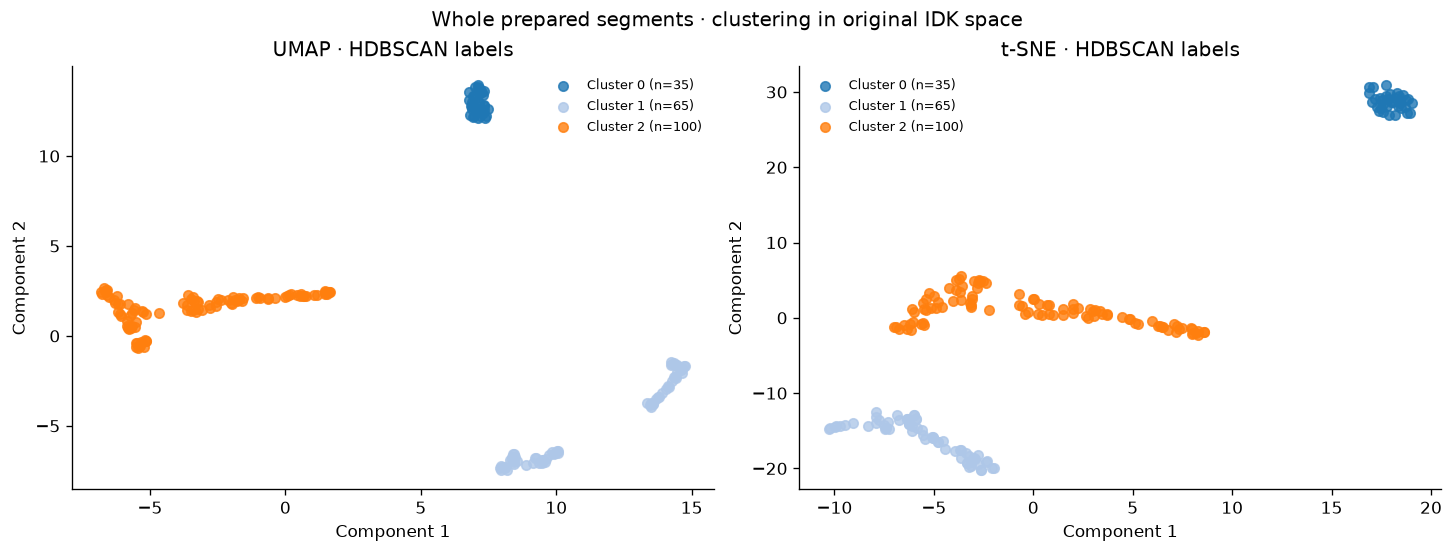

In [6]:
def plot_clusters(ax, coordinates, labels, title):
    """Use consistent categorical colors and a separate gray marker for noise."""
    for label in sorted(np.unique(labels)):
        selected = labels == label
        ax.scatter(
            coordinates[selected, 0],
            coordinates[selected, 1],
            c=["#999999" if label < 0 else plt.get_cmap("tab20")(int(label) % 20)],
            marker="x" if label < 0 else "o",
            s=32,
            alpha=0.8,
            label="Noise (-1)" if label < 0 else f"Cluster {label} (n={selected.sum()})",
        )
    ax.set(title=title, xlabel="Component 1", ylabel="Component 2")
    ax.legend(fontsize=8, frameon=False)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, (name, coordinates) in zip(axes, projections.items(), strict=True):
    plot_clusters(ax, coordinates, hdbscan_result.labels, f"{name} · HDBSCAN labels")
fig.suptitle("Whole prepared segments · clustering in original IDK space")
fig.savefig(OUTPUT_DIR / "hdbscan_umap_tsne.png", dpi=180)
plt.show()

## Spectral comparison and source returns

Reuse the same projection coordinates so only the labels change. Cluster IDs are
arbitrary and colors do not establish correspondence between the two algorithms.
The return plot helps interpret HDBSCAN groups using original episode outcomes.


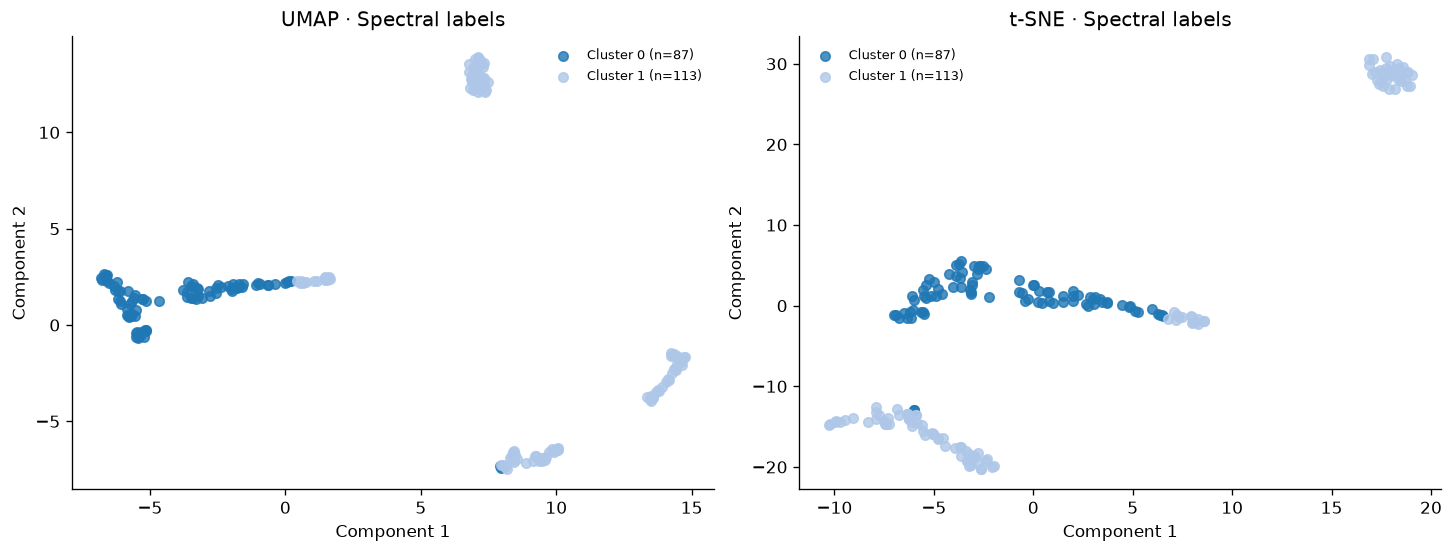

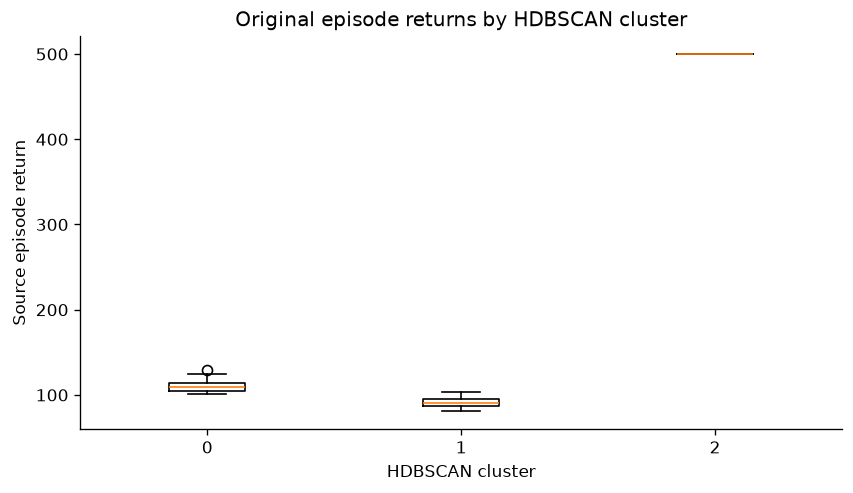

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
for ax, (name, coordinates) in zip(axes, projections.items(), strict=True):
    plot_clusters(ax, coordinates, spectral_result.labels, f"{name} · Spectral labels")
fig.savefig(OUTPUT_DIR / "spectral_umap_tsne.png", dpi=180)
plt.show()

cluster_ids = sorted(np.unique(hdbscan_result.labels))
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.boxplot(
    [
        units.loc[hdbscan_result.labels == label, "source_return"].to_numpy()
        for label in cluster_ids
    ],
    tick_labels=["Noise" if label < 0 else str(label) for label in cluster_ids],
)
ax.set(
    xlabel="HDBSCAN cluster",
    ylabel="Source episode return",
    title="Original episode returns by HDBSCAN cluster",
)
fig.savefig(OUTPUT_DIR / "hdbscan_source_returns.png", dpi=180)
plt.show()

## Save assignments, coordinates, and settings

The output directory contains per-unit assignments, membership strengths, both 2D
coordinates, quantitative summaries, and PNG figures. Re-running replaces these
notebook outputs, leaving the input artifact unchanged. Checkpoint and success are
related in this population, so their agreement with clusters is descriptive evidence,
not a held-out failure-detection evaluation.


In [8]:
assignments = units.copy()
assignments["hdbscan_cluster"] = hdbscan_result.labels
assignments["hdbscan_membership_strength"] = hdbscan_result.probabilities
assignments["spectral_cluster"] = spectral_result.labels
assignments[["umap_1", "umap_2"]] = umap_coordinates
assignments[["tsne_1", "tsne_2"]] = tsne_coordinates
assignments.to_parquet(OUTPUT_DIR / "assignments.parquet", index=False)
metrics.to_csv(OUTPUT_DIR / "metrics.csv")
hdbscan_summary.to_csv(OUTPUT_DIR / "hdbscan_summary.csv", index=False)
hdbscan_composition.to_csv(OUTPUT_DIR / "hdbscan_composition.csv", index=False)

settings = {
    "artifact": str(ARTIFACT_DIR.relative_to(ROOT)),
    "artifact_id": artifact.metadata.artifact_id,
    "fit_id": embedded.basis_id,
    "seed": SEED,
    "hdbscan": hdbscan_config.model_dump(mode="json"),
    "spectral": spectral_config.model_dump(mode="json"),
    "umap": {
        "metric": "precomputed",
        "n_neighbors": UMAP_NEIGHBORS,
        "min_dist": UMAP_MIN_DIST,
        "n_components": 2,
    },
    "tsne": {
        "metric": "precomputed",
        "perplexity": TSNE_PERPLEXITY,
        "init": "random",
        "learning_rate": "auto",
        "max_iter": 1500,
        "n_components": 2,
        "kl_divergence": float(tsne_model.kl_divergence_),
    },
    "versions": {
        name: version(name)
        for name in ["cartpole-idk", "numpy", "scikit-learn", "umap-learn", "matplotlib"]
    },
}
(OUTPUT_DIR / "settings.json").write_text(json.dumps(settings, indent=2) + "\n")
print(f"Saved results to {OUTPUT_DIR.relative_to(ROOT)}")

Saved results to artifacts/analysis/cluster-example-whole
